# Laboratorio 2 — Complejidad y búsqueda de hiperparámetros

**Integrantes:**  
- Julian Pinto 202321207  
- Daniel Vergara 202320392  

Este notebook es una **base sencilla, punto a punto**, para desarrollar el laboratorio.  
La idea es completar cada sección con el código, resultados, gráficas y justificaciones propias.


## 0. Importaciones y configuración

Importar las librerías necesarias para el laboratorio.


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42

## 1. Carga de datos

Usar el mismo conjunto de datos del Laboratorio 1, **pero en su versión resultante del proceso de limpieza y preparación**, tal como pide el enunciado.


In [17]:
DATA_PATH = "data/Datos Lab 1.csv"
TARGET = "temp_max_manana"

data = pd.read_csv(DATA_PATH)
data.head()


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,...,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,...,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,...,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,...,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,...,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


## 2. Separación de variables predictoras y objetivo

Definir:
- `X`: variables predictoras
- `y`: temperatura máxima

Después dividir en entrenamiento y prueba.


In [18]:
model_data = data.dropna(subset=[TARGET]).copy()
X = model_data.select_dtypes(include=np.number).drop(columns=[TARGET])
y = model_data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE
)

print(f"Datos utilizables: {model_data.shape[0]} filas, {X.shape[1]} predictoras numéricas")
print(f"Entrenamiento: {X_train.shape}; prueba: {X_test.shape}")
print(f"Valores ausentes en X: {X.isna().sum().sum()}")

Datos utilizables: 2481 filas, 22 predictoras numéricas
Entrenamiento: (1860, 22); prueba: (621, 22)
Valores ausentes en X: 1624


# Punto 1. Regresión polinomial

Construir un `Pipeline` con:
1. Características polinomiales.
2. Estrategia de escalamiento.
3. Regresión lineal.

Usar `GridSearchCV` para explorar:
- grado del polinomio;
- estrategia de escalamiento.

Reportar:
- RMSE
- MAE
- R²

También analizar si al aumentar el grado aparecen señales de sobreajuste.


In [19]:
pipeline_poly = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

param_grid_poly = {
    "poly__degree": [1, 2, 3, 4],
    "scaler": [StandardScaler(), MinMaxScaler(), "passthrough"]
}

grid_poly = GridSearchCV(
    pipeline_poly,
    param_grid_poly,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True
)

grid_poly.fit(X_train, y_train)
print("Mejores hiperparámetros:", grid_poly.best_params_)
print("Mejor RMSE CV:", -grid_poly.best_score_)

Mejores hiperparámetros: {'poly__degree': 1, 'scaler': StandardScaler()}
Mejor RMSE CV: 7.298423593237198


### Evaluación en test


In [20]:
best_poly = grid_poly.best_estimator_
y_pred_poly = best_poly.predict(X_test)

rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
mae_poly = mean_absolute_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f"RMSE: {rmse_poly:.4f}")
print(f"MAE: {mae_poly:.4f}")
print(f"R²: {r2_poly:.4f}")

RMSE: 41.1569
MAE: 7.1107
R²: -19.5064


### Análisis del Punto 1

La búsqueda seleccionó un polinomio de grado 1 con `StandardScaler` y RMSE medio de validación cruzada de aproximadamente 7.30. En el conjunto de prueba obtuvo RMSE 41.16, MAE 7.11 y R² -19.51. La diferencia entre RMSE y MAE evidencia que unas pocas predicciones extremas dominan el error cuadrático. El aumento de grado no mejora la generalización: el modelo aprende muy bien entrenamiento, pero la validación se deteriora de forma marcada, señal de sobreajuste e inestabilidad numérica.

# Punto 2. Curvas de validación

Analizar el desempeño del modelo polinomial para diferentes grados.

La gráfica debe mostrar:
- error promedio de entrenamiento;
- error promedio de validación;
- variabilidad del error.

Interpretar usando:
- sesgo;
- varianza;
- complejidad;
- sobreajuste.


In [21]:
degrees = [1, 2, 3, 4]
train_rmse_mean = []
train_rmse_std = []
val_rmse_mean = []
val_rmse_std = []

for degree in degrees:
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error",
        return_train_score=True,
        n_jobs=-1
    )

    train_scores = -scores["train_score"]
    val_scores = -scores["test_score"]

    train_rmse_mean.append(train_scores.mean())
    train_rmse_std.append(train_scores.std())
    val_rmse_mean.append(val_scores.mean())
    val_rmse_std.append(val_scores.std())

validation_curve_results = pd.DataFrame({
    "grado": degrees,
    "RMSE_train": train_rmse_mean,
    "RMSE_train_std": train_rmse_std,
    "RMSE_validacion": val_rmse_mean,
    "RMSE_validacion_std": val_rmse_std
})
validation_curve_results

,grado,RMSE_train,RMSE_train_std,RMSE_validacion,RMSE_validacion_std
0,1,7.192182e+00,8.780379e-02,7.298424,0.345965
1,2,4.647530e+00,1.220547e-01,70.538328,70.100811
2,3,1.025219e+00,5.026619e-02,2691.419879,2771.629507
3,4,1.072673e-12,1.230962e-13,670.993657,835.918198


### Análisis del Punto 2

El grado 1 presenta errores de entrenamiento y validación cercanos (RMSE aproximados de 7.19 y 7.30). Desde el grado 2, el error de entrenamiento baja, pero el de validación sube fuertemente: aproximadamente 70.54 en grado 2, 2691.42 en grado 3 y 670.99 en grado 4, con desviaciones estándar muy grandes. El sobreajuste comienza en grado 2. Esto ilustra el trade-off sesgo-varianza: aumentar la complejidad reduce el sesgo en entrenamiento, pero aumenta la varianza y empeora la generalización.

# Punto 3. Regresión regularizada: Ridge y Lasso

Construir dos pipelines:
- Ridge (L2)
- Lasso (L1)

Explorar con `GridSearchCV`:
- parámetro `alpha`;
- estrategia de escalamiento.

Comparar:
- regresión lineal sin regularización;
- Ridge;
- Lasso.

Además:
- analizar magnitud de coeficientes;
- en Lasso revisar qué coeficientes quedan en cero.


In [22]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

pipeline_ridge = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

param_grid_ridge = {
    "scaler": [StandardScaler(), MinMaxScaler(), "passthrough"],
    "model__alpha": alphas
}

grid_ridge = GridSearchCV(
    pipeline_ridge,
    param_grid_ridge,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_ridge.fit(X_train, y_train)
print("Ridge:", grid_ridge.best_params_, "RMSE CV:", -grid_ridge.best_score_)

pipeline_lasso = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Lasso(max_iter=20000, random_state=RANDOM_STATE))
])

param_grid_lasso = {
    "scaler": [StandardScaler(), MinMaxScaler(), "passthrough"],
    "model__alpha": alphas
}

grid_lasso = GridSearchCV(
    pipeline_lasso,
    param_grid_lasso,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_lasso.fit(X_train, y_train)
print("Lasso:", grid_lasso.best_params_, "RMSE CV:", -grid_lasso.best_score_)

pipeline_linear = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler()),
    ("model", LinearRegression())
])

linear_cv = cross_validate(
    pipeline_linear,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
linear_cv_rmse = -linear_cv["test_score"]
pipeline_linear.fit(X_train, y_train)

print(
    "Lineal sin regularización:",
    f"RMSE CV medio: {linear_cv_rmse.mean():.4f}",
    f"| std: {linear_cv_rmse.std():.4f}"
)


Ridge: {'model__alpha': 1, 'scaler': MinMaxScaler()} RMSE CV: 7.2876228234572835
Lasso: {'model__alpha': 0.01, 'scaler': MinMaxScaler()} RMSE CV: 7.280727917217947
Lineal sin regularización: RMSE CV medio: 7.2984 | std: 0.3460


In [23]:
# pipeline_lasso = Pipeline([
#     ("scaler", StandardScaler()),
#     ("model", Lasso(max_iter=10000))
# ])

# param_grid_lasso = {
#     "scaler": [StandardScaler(), MinMaxScaler(), "passthrough"],
#     "model__alpha": alphas
# }

# grid_lasso = GridSearchCV(
#     pipeline_lasso,
#     param_grid_lasso,
#     cv=5,
#     scoring="neg_root_mean_squared_error",
#     n_jobs=-1
# )

# grid_lasso.fit(X_train, y_train)
# print(grid_lasso.best_params_, -grid_lasso.best_score_)


### Evaluación en test


In [24]:
best_linear = pipeline_linear
best_ridge = grid_ridge.best_estimator_
best_lasso = grid_lasso.best_estimator_

def test_metrics(model, name):
    predictions = model.predict(X_test)
    return {
        "Modelo": name,
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
        "MAE": mean_absolute_error(y_test, predictions),
        "R2": r2_score(y_test, predictions)
    }

resultados_reg = pd.DataFrame([
    test_metrics(best_linear, "Lineal"),
    test_metrics(best_ridge, "Ridge"),
    test_metrics(best_lasso, "Lasso")
])
resultados_reg


,Modelo,RMSE,MAE,R2
0,Lineal,41.156856,7.110719,-19.506394
1,Ridge,30.139229,6.657290,-9.996872
2,Lasso,7.147544,5.513453,0.381530


### Coeficientes

Aquí revisar:
- cómo cambia la magnitud de los coeficientes con Ridge;
- cuáles coeficientes Lasso lleva a cero;
- qué significa eso para interpretabilidad y selección de variables.


In [25]:
coef_linear = best_linear.named_steps["model"].coef_
coef_lasso = best_lasso.named_steps["model"].coef_
coef_ridge = best_ridge.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "Variable": X_train.columns,
    "Lineal": coef_linear,
    "Ridge": coef_ridge,
    "Lasso": coef_lasso
})
coef_df["Lasso_cero"] = np.isclose(coef_df["Lasso"], 0.0, atol=1e-8)
coef_df = coef_df.sort_values("Lasso", key=np.abs, ascending=False)

print(f"Variables con coeficiente Lasso igual a cero: {coef_df['Lasso_cero'].sum()} de {len(coef_df)}")
coef_df


Variables con coeficiente Lasso igual a cero: 9 de 22


,Variable,Lineal,Ridge,Lasso,Lasso_cero
7,humedad_desv,23.879654,23.549572,23.955680,False
3,presion_desv,-14.780718,-13.420593,-13.210563,False
6,humedad_max,-8.107671,-7.961954,-7.225725,False
21,dia_del_anio,6.461201,6.372917,6.212630,False
17,viento_este,-6.884957,-5.942028,-3.769936,False
15,rafaga_desv,-3.617503,-2.905401,-2.671507,False
20,anio,2.642224,2.629084,2.533194,False
5,humedad_min,-3.117773,-3.136928,-2.457423,False
18,direccion_viento,-3.004065,-2.715547,-1.991647,False
10,viento_max,-1.219424,-0.097365,1.462280,False


# Punto 4. Regresión polinomial regularizada

Crear un pipeline que combine:
1. PolynomialFeatures
2. Escalamiento
3. Ridge o Lasso

Explorar:
- grado;
- alpha;
- escalamiento.

Evaluar con RMSE, MAE y R².


In [26]:
pipeline_poly_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

param_grid_poly_reg = {
    "poly__degree": [1, 2, 3],
    "scaler": [StandardScaler(), MinMaxScaler(), "passthrough"],
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

grid_poly_reg = GridSearchCV(
    pipeline_poly_reg,
    param_grid_poly_reg,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_poly_reg.fit(X_train, y_train)
print("Mejores hiperparámetros:", grid_poly_reg.best_params_)
print("Mejor RMSE CV:", -grid_poly_reg.best_score_)

Mejores hiperparámetros: {'model__alpha': 1, 'poly__degree': 2, 'scaler': MinMaxScaler()}
Mejor RMSE CV: 5.930649560388399


In [27]:
best_poly_reg = grid_poly_reg.best_estimator_
poly_reg_metrics = test_metrics(best_poly_reg, "Polinomial Ridge")
print(f"RMSE: {poly_reg_metrics['RMSE']:.4f}")
print(f"MAE: {poly_reg_metrics['MAE']:.4f}")
print(f"R²: {poly_reg_metrics['R2']:.4f}")

RMSE: 21244.0068
MAE: 856.3934
R²: -5463584.6739


### Análisis del Punto 4

La búsqueda del polinomio Ridge seleccionó grado 2, `alpha=1` y `MinMaxScaler`, con RMSE CV de 5.93. Sin embargo, su RMSE de test fue 21244.01 y su R² fue muy negativo, acompañado de advertencias de matriz mal condicionada. Por tanto, la regularización no controló suficientemente la inestabilidad de esta configuración. Este resultado muestra por qué no basta con escoger el menor promedio de validación: también hay que revisar la desviación estándar, el comportamiento en test y la estabilidad numérica.

# Punto 5. Comparación y selección del mejor modelo

Construir una tabla comparando los modelos de los puntos 1, 3 y 4.

No seleccionar solamente por promedio:
- mirar RMSE medio;
- desviación estándar;
- complejidad;
- interpretabilidad.


In [28]:
def cv_summary(search, name):
    best_index = search.best_index_
    cv_results = search.cv_results_
    metrics_test = test_metrics(search.best_estimator_, name)
    return {
        "Modelo": name,
        "Hiperparámetros": search.best_params_,
        "RMSE_CV_medio": -cv_results["mean_test_score"][best_index],
        "RMSE_CV_std": cv_results["std_test_score"][best_index],
        "RMSE_test": metrics_test["RMSE"],
        "MAE_test": metrics_test["MAE"],
        "R2_test": metrics_test["R2"]
    }

linear_test = test_metrics(best_linear, "Lineal")
linear_summary = {
    "Modelo": "Lineal",
    "Hiperparámetros": {"scaler": "MinMaxScaler"},
    "RMSE_CV_medio": linear_cv_rmse.mean(),
    "RMSE_CV_std": linear_cv_rmse.std(),
    "RMSE_test": linear_test["RMSE"],
    "MAE_test": linear_test["MAE"],
    "R2_test": linear_test["R2"]
}

comparacion = pd.DataFrame([
    cv_summary(grid_poly, "Polinomial"),
    linear_summary,
    cv_summary(grid_ridge, "Ridge"),
    cv_summary(grid_lasso, "Lasso"),
    cv_summary(grid_poly_reg, "Polinomial Ridge")
]).sort_values("RMSE_CV_medio")

comparacion


,Modelo,Hiperparámetros,RMSE_CV_medio,RMSE_CV_std,RMSE_test,MAE_test,R2_test
4,Polinomial Ridge,"{'model__alpha': 1, 'poly__degree': 2, 'scaler...",5.930650,0.855451,21244.006758,856.393393,-5.463585e+06
3,Lasso,"{'model__alpha': 0.01, 'scaler': MinMaxScaler()}",7.280728,0.327770,7.147544,5.513453,3.815300e-01
2,Ridge,"{'model__alpha': 1, 'scaler': MinMaxScaler()}",7.287623,0.334035,30.139229,6.657290,-9.996872e+00
0,Polinomial,"{'poly__degree': 1, 'scaler': StandardScaler()}",7.298424,0.345965,41.156856,7.110719,-1.950639e+01
1,Lineal,{'scaler': 'MinMaxScaler'},7.298424,0.345965,41.156856,7.110719,-1.950639e+01


### Modelo seleccionado

**Modelo elegido:** Lasso con `alpha=0.01` y `MinMaxScaler`.

**Justificación:** El polinomio Ridge obtuvo el menor RMSE promedio en validación cruzada (aprox. 5.93), pero también presentó una desviación estándar mayor (aprox. 0.86) y una complejidad superior al usar características polinomiales de grado 2. Lasso obtuvo un RMSE CV de aproximadamente 7.28 con una desviación estándar cercana a 0.33, además de reducir 9 de 22 coeficientes a cero. Por balance entre desempeño, estabilidad, complejidad e interpretabilidad, se seleccionó Lasso.

El conjunto de **test no se utiliza para escoger el modelo**; se reserva únicamente para evaluar el desempeño final una vez tomada la decisión con validación cruzada.


# Punto 6. Intervalos de confianza con bootstrapping

Usar el modelo seleccionado.

Aplicar al menos **500 remuestreos** sobre el conjunto de test.

Para cada muestra calcular métricas, por ejemplo:
- RMSE;
- MAE;
- R².

Después calcular:
- promedio;
- intervalo de confianza del 95%.

También graficar la distribución de los errores.


In [29]:
best_model_name = "Lasso"
best_model = best_lasso

print(f"Modelo seleccionado con base en CV, estabilidad y complejidad: {best_model_name}")

rng = np.random.default_rng(RANDOM_STATE)
n_bootstrap = 1000
bootstrap_metrics = []
y_test_array = np.asarray(y_test)

for _ in range(n_bootstrap):
    indices = rng.integers(0, len(X_test), len(X_test))
    X_boot = X_test.iloc[indices]
    y_boot = y_test_array[indices]
    pred_boot = best_model.predict(X_boot)

    bootstrap_metrics.append({
        "RMSE": np.sqrt(mean_squared_error(y_boot, pred_boot)),
        "MAE": mean_absolute_error(y_boot, pred_boot),
        "R2": r2_score(y_boot, pred_boot)
    })

bootstrap_df = pd.DataFrame(bootstrap_metrics)
intervalos_bootstrap = pd.DataFrame({
    "Métrica": bootstrap_df.columns,
    "Promedio": bootstrap_df.mean().values,
    "IC95_inferior": bootstrap_df.quantile(0.025).values,
    "IC95_superior": bootstrap_df.quantile(0.975).values
})

intervalos_bootstrap


Modelo seleccionado con base en CV, estabilidad y complejidad: Lasso


,Métrica,Promedio,IC95_inferior,IC95_superior
0,RMSE,7.130535,6.554560,7.777952
1,MAE,5.512227,5.184740,5.865507
2,R2,0.379460,0.303415,0.449246


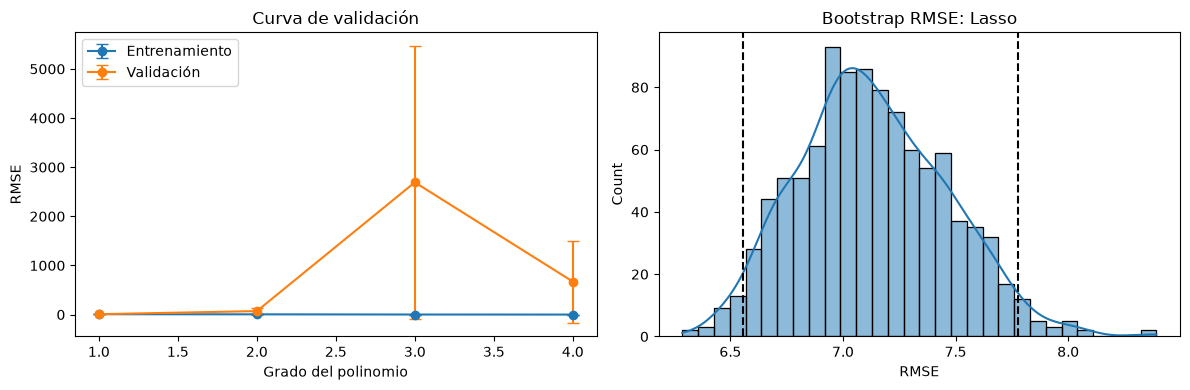

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].errorbar(
    degrees,
    train_rmse_mean,
    yerr=train_rmse_std,
    marker="o",
    capsize=4,
    label="Entrenamiento"
)
axes[0].errorbar(
    degrees,
    val_rmse_mean,
    yerr=val_rmse_std,
    marker="o",
    capsize=4,
    label="Validación"
)
axes[0].set_xlabel("Grado del polinomio")
axes[0].set_ylabel("RMSE")
axes[0].set_title("Curva de validación")
axes[0].legend()

sns.histplot(bootstrap_df["RMSE"], bins=30, ax=axes[1], kde=True)
axes[1].axvline(intervalos_bootstrap.loc[0, "IC95_inferior"], linestyle="--", color="black")
axes[1].axvline(intervalos_bootstrap.loc[0, "IC95_superior"], linestyle="--", color="black")
axes[1].set_title(f"Bootstrap RMSE: {best_model_name}")
axes[1].set_xlabel("RMSE")

plt.tight_layout()
plt.show()

### Análisis del Punto 6

Para Lasso, el bootstrap de 1000 remuestreos produjo IC 95% de RMSE [6.55, 7.78], MAE [5.18, 5.87] y R² [0.303, 0.449]. Los intervalos son relativamente estrechos frente a la escala del error y se mantienen en valores razonables, lo que sugiere estabilidad moderada. Aun así, el modelo explica cerca del 38% de la variación en test, por lo que sus predicciones deben usarse como apoyo y acompañarse de monitoreo y revisión de casos extremos.

# Punto 7. Análisis de resultados

Responder de forma breve pero sustentada las preguntas del enunciado.


## Análisis cuantitativo

### 1. ¿Cuál modelo obtuvo el mejor desempeño en test?
Lasso obtuvo el mejor desempeño en test entre los modelos evaluados: RMSE 7.15, MAE 5.51 y R² 0.382. El polinomio Ridge presentó un RMSE CV atractivo, pero su desempeño en test fue muy deficiente.

### 2. ¿Coincide con el mejor promedio en validación cruzada?
No. El menor RMSE CV fue el del polinomio Ridge, mientras que el mejor desempeño en test fue el de Lasso. Esto puede deberse a mayor varianza, sensibilidad a valores extremos y mal condicionamiento de las características polinomiales.

### 3. ¿El modelo con mejor métrica promedio es necesariamente el más adecuado?
No. La selección debe considerar también la desviación estándar en validación cruzada, la complejidad y la interpretabilidad. Por eso se seleccionó Lasso: aunque su RMSE CV promedio es mayor que el del polinomio Ridge, presentó menor variabilidad y una estructura más simple. El conjunto de test se utiliza después únicamente como evaluación final.

### 4. ¿Cómo cambia el error con la complejidad y dónde aparece sobreajuste?
El error de entrenamiento disminuye al aumentar el grado, mientras el error de validación aumenta desde grado 2. El sobreajuste aparece desde ese punto y se intensifica en grado 3.

### 5. ¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?
Ridge reduce gradualmente la magnitud de los coeficientes, mientras Lasso puede llevarlos exactamente a cero. Esto ayuda a controlar la complejidad y, en Lasso, permite una selección automática de variables, aunque puede omitir variables correlacionadas.

### 6. ¿Qué indican los intervalos de confianza?
Los intervalos bootstrap de Lasso muestran variabilidad moderada: el RMSE se concentra entre 6.55 y 7.78 y el R² entre 0.303 y 0.449. Las predicciones son razonablemente estables, pero no libres de incertidumbre.


## Análisis cualitativo

### 1. ¿Qué variables fueron más relevantes para Lasso?
Las variables con mayor magnitud absoluta en Lasso fueron `humedad_desv`, `presion_desv`, `humedad_max`, `dia_del_anio` y `viento_este`. Nueve de las 22 variables quedaron con coeficiente cero. Esta lista debe interpretarse como asociación predictiva, no como causalidad.

### 2. ¿Qué interpretación práctica tienen los coeficientes del modelo final?
El signo indica la dirección de la asociación manteniendo constantes las demás variables, y la magnitud depende de la escala transformada. Por eso la interpretación debe hacerse con cautela y preferiblemente contrastarse con unidades originales y conocimiento meteorológico.

### 3. ¿Hay diferencias entre el modelo más preciso y el más interpretable?
Sí. Los polinomios pueden obtener errores bajos en entrenamiento o CV, pero son difíciles de interpretar y pueden ser inestables. Lasso ofrece un desempeño competitivo, menor complejidad efectiva y selección explícita de variables.

### 4. ¿Qué decisiones estratégicas podría tomar AlpesPlanck?
Usar Lasso como línea base operativa, monitorear el error y los intervalos de confianza, investigar los días con errores extremos y revisar periódicamente si cambian las relaciones meteorológicas.

### 5. ¿Mayor precisión implica necesariamente mayor valor?
No. La precisión debe balancearse con estabilidad, interpretabilidad, costo de mantenimiento y consecuencias de los errores.

### 6. ¿Un modelo más complejo necesariamente genera mayor valor empresarial?
No. En este experimento la complejidad polinomial aumentó la inestabilidad y redujo la utilidad operativa. Un modelo simple y confiable puede generar más valor que uno más preciso solo en entrenamiento.

## Reflexión conceptual

### 1. Relación entre complejidad, generalización y estabilidad
La complejidad aumenta la capacidad de representar patrones, pero también la varianza. En los resultados, grados superiores redujeron el error de entrenamiento y empeoraron fuertemente la validación, por lo que la generalización exige controlar la complejidad.

### 2. Posibles fuentes de sesgo
Puede haber valores faltantes no aleatorios, errores de medición, variables meteorológicas con escalas y calidad desigual, dependencia temporal entre días y datos extremos. Además, usar solo variables numéricas excluye información categórica potencialmente útil.

### 3. ¿Qué pasaría con la estabilidad si aumentara el tamaño de muestra?
En general, más observaciones representativas reducen la varianza de las estimaciones y estrechan los intervalos de confianza. El beneficio depende de que los nuevos datos cubran adecuadamente estaciones, años y condiciones meteorológicas, y no sean simplemente duplicados de los existentes.

# Uso de herramientas de IA generativa

El laboratorio exige documentar explícitamente el uso de IA.

## Declaración de uso
**Herramientas:** GitHub Copilot y ChatGPT.  
**Tipo de uso:** apoyo conceptual, corrección de errores en el código, ayuda con el formato en Markdown, creación de un notebook base (.ipynb) para guiar el desarrollo del taller y apoyo puntual en algunos análisis e interpretaciones.

## Prompts principales
- Crea un notebook base en formato .ipynb para desarrollar un laboratorio de Machine Learning sobre regresión polinomial, regularización, búsqueda de hiperparámetros, curvas de validación y bootstrap. Déjalo organizado por secciones para completarlo con mis propios resultados.
- Me aparece un error al calcular el RMSE con mean_squared_error(..., squared=False). ¿Cómo puedo corregirlo en mi versión de scikit-learn sin cambiar la lógica de evaluación?
- Revisa si este pipeline con SimpleImputer, PolynomialFeatures, StandardScaler y GridSearchCV está bien planteado para evitar fuga de datos entre entrenamiento, validación y prueba.
- Ayúdame a validar si estos resultados tienen sentido: el error de entrenamiento baja al subir el grado del polinomio, pero el error de validación aumenta mucho. ¿Cómo lo explico usando sesgo, varianza y sobreajuste?
- Dame una sugerencia de redacción breve en Markdown para explicar por qué Lasso puede ser una mejor opción que un modelo polinomial más complejo cuando se consideran estabilidad, interpretabilidad y desempeño en test.

## Análisis crítico del resultado
Las respuestas generadas por la IA fueron útiles principalmente como guía de estructura y como apoyo para resolver dudas puntuales. En particular, sirvieron para organizar el notebook, recordar la sintaxis de Pipeline, GridSearchCV y validación cruzada, y proponer formas claras de redactar algunos análisis. También ayudaron a identificar errores concretos, como el uso de un parámetro no disponible en la versión instalada de scikit-learn y la necesidad de calcular el RMSE aplicando explícitamente la raíz cuadrada del MSE.

Sin embargo, las respuestas no se usaron de forma automática. Fue necesario revisar que el código correspondiera al dataset real, verificar la columna objetivo, decidir cómo tratar los valores faltantes, ejecutar los modelos y contrastar los resultados obtenidos. Algunas sugerencias eran demasiado generales y tuvieron que adaptarse al enunciado del laboratorio y a los conceptos vistos en clase. Por ejemplo, la selección del modelo no se basó solo en el menor error, sino también en la variabilidad en validación cruzada, el riesgo de sobreajuste, la regularización y la interpretabilidad. Estos criterios del curso permitieron evaluar cuándo una respuesta de la IA era razonable y cuándo debía modificarse.

## Aportes propios
La mayor parte del trabajo fue desarrollada y decidida nosotros. Se cargó el dataset correspondiente, se definieron las variables predictoras y la variable objetivo, se ejecutaron los experimentos, se ajustaron los hiperparámetros evaluados y se analizaron los resultados obtenidos en entrenamiento, validación cruzada, prueba y bootstrap. También se revisaron las gráficas y métricas para justificar la presencia de sobreajuste en modelos polinomiales de mayor grado y la elección de Lasso como alternativa más estable e interpretable.

A partir del apoyo de la IA se hicieron ajustes propios sobre el código y las explicaciones: se corrigieron errores de ejecución, se adaptaron los pipelines al conjunto de datos usado, se separó la evaluación final en test del proceso de selección del modelo y se reescribieron los análisis para que reflejaran los resultados reales del notebook.
